In [22]:
import pandas as pd
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Load the dataset
file_path = r"C:\Users\adity\Desktop\IANT PYTHON\Task first\Customer Satisfaction Survey Analysis\Customer_Satisfaction_Survey.csv"
data = pd.read_csv(file_path)

## Text Preprocessing

In [23]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

# Preprocessing function
def preprocess_text(text):
    text = re.sub(r'\W', ' ', str(text))  # Remove special characters
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    text = re.sub(r'\d', '', text)  # Remove digits
    tokens = text.split()  # Tokenize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stopwords.words('english')]
    return ' '.join(tokens)

# Apply preprocessing
data['ProcessedFeedback'] = data['CustomerFeedback'].apply(preprocess_text)
print(data[['CustomerFeedback', 'ProcessedFeedback']].head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adity\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\adity\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                CustomerFeedback         ProcessedFeedback
0  Customer support was helpful.  customer support helpful
1             Delivery was late.             delivery late
2                Very satisfied!                 satisfied
3             Price is too high.                price high
4             Price is too high.                price high


## Exploratory Data Analysis (EDA)

In [24]:
from collections import Counter

# Word frequency
all_words = ' '.join(data['ProcessedFeedback']).split()
word_freq = Counter(all_words)
print(word_freq.most_common(10))


[('product', 1008), ('satisfied', 531), ('issue', 527), ('billing', 527), ('great', 517), ('service', 517), ('quality', 506), ('need', 506), ('improvement', 506), ('meet', 502)]


 ## Sentiment Analysis

In [25]:
from textblob import TextBlob

# Sentiment analysis
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

data['Sentiment'] = data['ProcessedFeedback'].apply(get_sentiment)
print(data[['CustomerFeedback', 'Sentiment']].head())


                CustomerFeedback Sentiment
0  Customer support was helpful.   Neutral
1             Delivery was late.  Negative
2                Very satisfied!  Positive
3             Price is too high.  Positive
4             Price is too high.  Positive


## Vectorization

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(data['ProcessedFeedback']).toarray()
print(X.shape)


(5050, 24)


## Model Building

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, data['CleanFeedback'], test_size=0.2, random_state=42)

Columns in dataset: Index(['CustomerID', 'SurveyDate', 'SatisfactionScore', 'CustomerFeedback',
       'AgeGroup', 'Gender', 'Region', 'RepeatCustomer', 'Sentiment',
       'YearMonth', 'CleanFeedback', 'IssueCategory', 'ProcessedFeedback'],
      dtype='object')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adity\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\adity\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


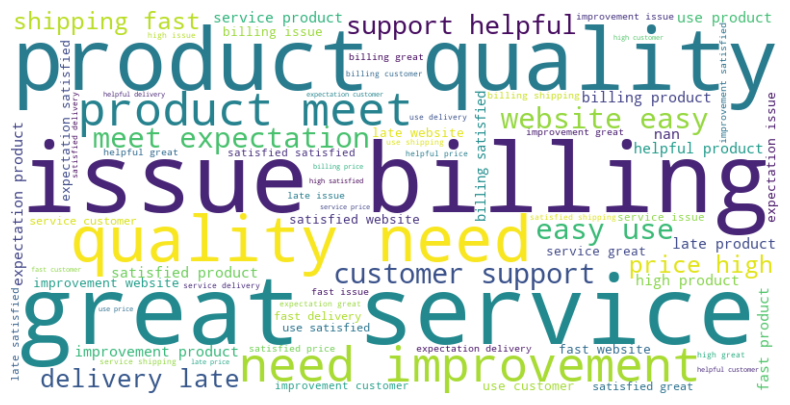

In [28]:
# Check available columns
print("Columns in dataset:", data.columns)

# Text preprocessing
nltk.download('stopwords')
nltk.download('wordnet')
def preprocess_text(text):
    text = re.sub(r'\W', ' ', str(text))
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\d', '', text)
    tokens = text.split()
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stopwords.words('english')]
    return ' '.join(tokens)

data['ProcessedFeedback'] = data['CustomerFeedback'].apply(preprocess_text)

# Sentiment analysis
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

data['Sentiment'] = data['ProcessedFeedback'].apply(get_sentiment)
# Word cloud visualization
all_words = ' '.join(data['ProcessedFeedback'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


 ## Visualization

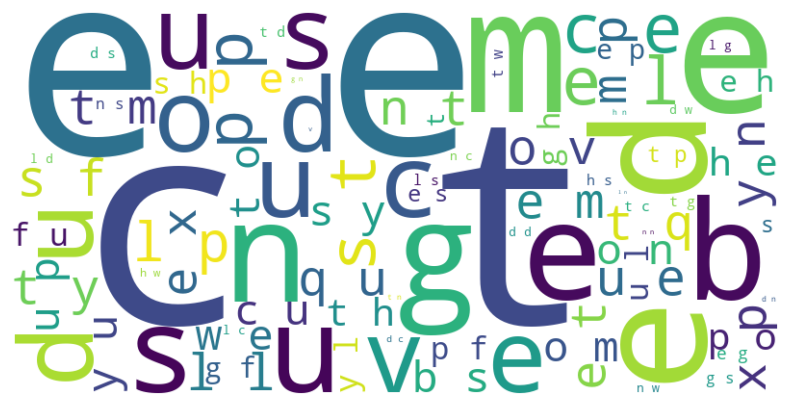

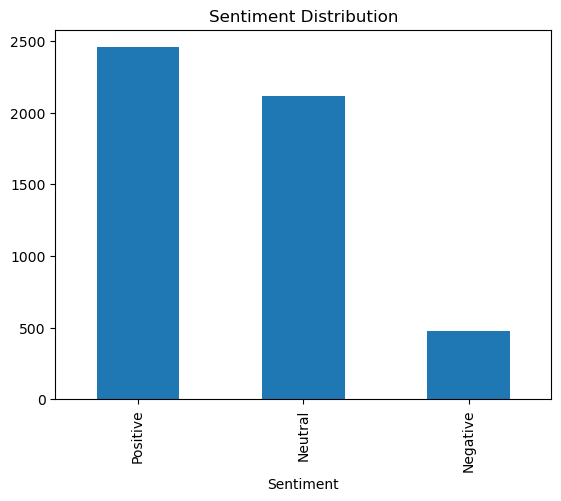

In [30]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_words))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Sentiment distribution
data['Sentiment'].value_counts().plot(kind='bar', title='Sentiment Distribution')
plt.show()


# Recommendations:
## 1) Address Common Issues:

### * Analyze the IssueCategory column for frequently reported problems.
### *Focus on resolving the most critical or recurring issues to enhance overall satisfaction.
## 2)Improve Customer Sentiment:

### *Focus on feedback categorized as "Negative" in the Sentiment column.
### *Implement training programs for customer-facing teams to improve service quality.
### *Introduce follow-up mechanisms for dissatisfied customers to rebuild trust.
## 3)Demographic-Specific Strategies:

### *Use insights from the AgeGroup and Gender columns to design targeted marketing campaigns.
### *Tailor product or service offerings to meet the preferences of specific customer segments.
## 4)Encourage Repeat Customers:

### *Utilize the RepeatCustomer column to identify loyal customers.
### *Offer loyalty programs, discounts, or exclusive benefits to incentivize repeat purchases.
## 5)Region-Specific Enhancements:

### *Use the Region column to identify geographical areas with lower satisfaction scores.
### *Deploy region-specific improvement plans to address localized issues.
## 6) Monitor Satisfaction Trends:

### *Analyze the YearMonth column to detect trends in satisfaction over time.
### *Identify seasonal patterns or anomalies and align operational strategies accordingly.
## 7) Promote Positivity:

### *Focus on amplifying positive feedback from the CustomerFeedback column.
### *Share success stories and testimonials from satisfied customers to attract new ones.

# Conclusion:
The analysis of the dataset reveals actionable insights for improving customer satisfaction and loyalty. By addressing specific pain points highlighted in the CustomerFeedback and IssueCategory columns, businesses can enhance their service quality. Additionally, leveraging demographic and regional data allows for a more personalized approach to customer engagement. Tracking trends over time ensures continuous improvement, fostering long-term customer relationships and brand growth.